# Implementing a (simplified) Denoising Diffusion Probabilistic Model (DDPM)

The final goal is to implement a simple DDPM, using inspiration from the [original paper](https://arxiv.org/abs/2006.11239). We will also introduce some simple modification inspired by the [DDIM paper](https://arxiv.org/pdf/2102.09672).

We will proceed incrementally, and complete the following tasks : 
- Load an image and add noise to it using inspiration from the DDPM paper by creating a noise generator function that can reproduce the effect of gradually adding noise to an image
- Create a simple denoiser with an "hourglass" shape
- Implement the training logic with the denoiser and the noise generator
- Train this setup on a subset of mnist dataset and qualitatively evaluate the results

Once those first steps are completed we will gradually add some improvments to try and improve our model 
- Improve the noise generator schedule by using inspiration from the DDIM paper
- Update the denoiser to add more layers and the skip connections as seen in the original unet
- Replace the simple conv layers by residual blocks
- Add group normalisation layers to the residual blocks
- Add Self-attention mechanism (with positionnal embeddings)

For each step some code skeleton will be provided, follow the comments to fill the missing parts, some helper function are also provided to speed up some parts

## Required imports

In [1]:
import torch
import random
import numpy as np
import torchvision
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
#from timm.utils import ModelEmaV3
import math

## Helper Functions

The following block contains elements needed to implement the self-attention layers in the Unet variant used in the DDPM paper. Il will be useful later.

In [2]:
class SinusoidalEmbeddings(nn.Module):
    """ Sinusoidal Embeddings encoder 

        For use with self-attention layers

        from https://towardsdatascience.com/diffusion-model-from-scratch-in-pytorch-ddpm-9d9760528946/

    """
    def __init__(self, time_steps:int, embed_dim: int):
        super().__init__()
        position = torch.arange(time_steps).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, embed_dim, 2).float() * -(math.log(10000.0) / embed_dim))
        embeddings = torch.zeros(time_steps, embed_dim, requires_grad=False)
        embeddings[:, 0::2] = torch.sin(position * div)
        embeddings[:, 1::2] = torch.cos(position * div)
        self.embeddings = embeddings

    def forward(self, x, t):
        embeds = self.embeddings[t].to(x.device)
        return embeds[:, :, None, None]

class SelfAttention(nn.Module):
    """ Self attention Layer
    
        from https://discuss.pytorch.org/t/attention-in-image-classification/80147/2

        Works with image tensor of any shape
        
    """
    def __init__(self,in_dim,activation):
        super(SelfAttention,self).__init__()
        self.chanel_in = in_dim
        self.activation = activation
        
        self.query_conv = nn.Conv2d(in_channels = in_dim , out_channels = in_dim//8 , kernel_size= 1)
        self.key_conv = nn.Conv2d(in_channels = in_dim , out_channels = in_dim//8 , kernel_size= 1)
        self.value_conv = nn.Conv2d(in_channels = in_dim , out_channels = in_dim , kernel_size= 1)
        self.gamma = nn.Parameter(torch.zeros(1))

        self.softmax  = nn.Softmax(dim=-1) #
    def forward(self,x):
        """
            inputs :
                x : input feature maps( B X C X W X H)
            returns :
                out : self attention value + input feature 
                attention: B X N X N (N is Width*Height)
        """
        m_batchsize,C,width ,height = x.size()
        proj_query  = self.query_conv(x).view(m_batchsize,-1,width*height).permute(0,2,1) # B X CX(N)
        proj_key =  self.key_conv(x).view(m_batchsize,-1,width*height) # B X C x (*W*H)
        energy =  torch.bmm(proj_query,proj_key) # transpose check
        attention = self.softmax(energy) # BX (N) X (N) 
        proj_value = self.value_conv(x).view(m_batchsize,-1,width*height) # B X C X N

        out = torch.bmm(proj_value,attention.permute(0,2,1) )
        out = out.view(m_batchsize,C,width,height)
        
        out = self.gamma*out + x
        return out,attention

### Check for GPU availability

In [3]:
# From IAO4 tutorial on GANs
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

#Additional Info when using cuda
if device == 'cuda':
    print('Number of GPU(s):', torch.cuda.device_count())
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using cuda device
Number of GPU(s): 1
NVIDIA GeForce GTX 1650 with Max-Q Design
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


### Adding simple gaussian noise to an image 

In order to introduce the noise generation process to see its effects first load an image using the PIL/Pillow library, convert it to a tensor (to be used with pytorch) and add noise to the image with the following schedule. 

The original schedule was : 
$ x_t = (1-\beta) \cdot x_{t-1} + \beta \cdot \epsilon $

For simplification purpose we will start by implementing a more direct noise generation process :
$ x_t = (1-\beta_t) \cdot x_0 + \beta_t \cdot \epsilon $

For this part, we will set $\beta_t$ as a constant between $0$ and $1$ and $\epsilon$ will represent the 2D noise added to the image (see `torch.rand_like` or `torch.randn` documentation to generate the noise)

Note : if you use the provided example or any other `.png` image, be sure to remove the "alpha" channel from your image befor the conversion to grayscale

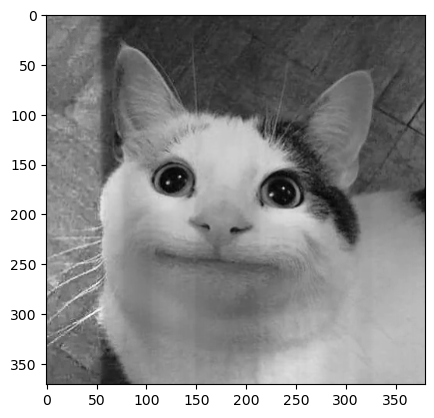

In [4]:
# Load an image using pillow and convert it to greyscale

img_raw = Image.open("./test_img.png") # Load an image 
img = torchvision.transforms.functional.pil_to_tensor(img_raw) # Convert to tensor
img = img[0:3,:,:] # Remove the alpha channel for simplification
img = torchvision.transforms.functional.rgb_to_grayscale(img) # Convert to grayscale (again for simplification)
img = img.float() # Convert to doubles 
img = F.normalize(img) # Normalize the image 
plt.imshow(img[0], cmap="Greys_r") # Display the image (ideally in black & white

In [5]:
# Now create a function to add some noise according to the simplified schedule 
# This function has to work with 4D tensors
def noise_generator(x_t, beta):
    # Generate 2D noise 
    epsilon = torch.rand_like(x_t) 
    # Add some dimensions to beta (to be able to work on a batch of multi-channel images 
    beta = beta.view(-1,1,1,1) 
    # Create the noisy version of the input
    x_t_1 = (1 - beta) * x_t + beta * epsilon 
    return x_t_1

# Create a function that generate the beta and alpha scheduling parameter as defined in the original paper
def DDPM_scheduler(t, beta):
    """
    Return the corresponding alpha and beta values for a specific timestep as definied in the DDPM paper
    """
    alpha = 1 - beta
    alphas = torch.cumprod(alpha, dim=0)
    alpha_t = alphas[t]
    alpha_t = alpha_t.view(-1,1,1,1)

    return alpha_t, beta[t].view(-1,1,1,1)

# Define a generator that create a noisy input using the scheduler defined above
def DDPM_noise_gen(x, t, beta):
    """
    Forward diffusion process : add 2D noise to a tensor
    """
    epsilon = torch.rand_like(x) 
    
    alpha_t, _ = DDPM_scheduler(t, beta)
    
    x_t = torch.sqrt(alpha_t)*x + torch.sqrt(1-alpha_t)*epsilon
    
    return x_t, alpha_t

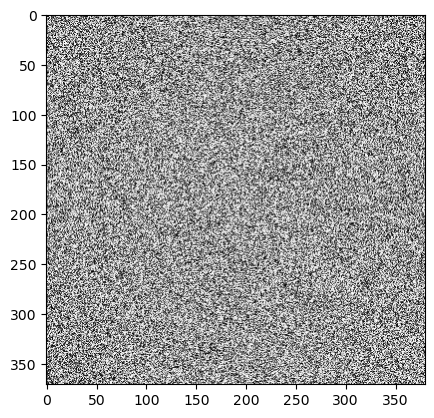

In [6]:
# Test your function on the image you loaded before
beta_schedule = torch.linspace(1e-4, 0.02, 1000)
# Choose a value for beta between 0 and 999
noisy_img = DDPM_noise_gen(img, [500], beta_schedule) 
plt.imshow(noisy_img[0][0][0], cmap="Greys_r")

### Apply the noise function with increasing strength on the Mnist dataset

C:\Users\bocca\anaconda3\Lib\site-packages\torchvision\datasets\mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")
C:\Users\bocca\anaconda3\Lib\site-packages\torchvision\datasets\mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


Text(0.5, 1.0, 'Number 3')

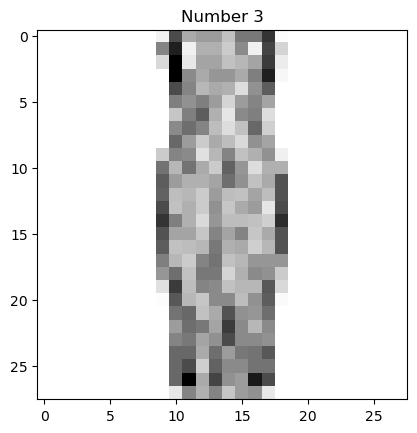

In [7]:
# Load the mnist dataset

data_transform = torchvision.transforms.Compose(
[torchvision.transforms.ToTensor(), torchvision.transforms.Normalize((0.5,), (0.5,))]
)

dataset = torchvision.datasets.FashionMNIST(
    root="fashionmnist/", train=True, download=True, transform=data_transform
)

# select and display a random image (as a sanity check)
idx = np.random.randint(0, len(dataset.train_data))
plt.imshow(dataset.train_data[idx], cmap='Grays') 
plt.title(f'Number {dataset.train_labels[idx]}')

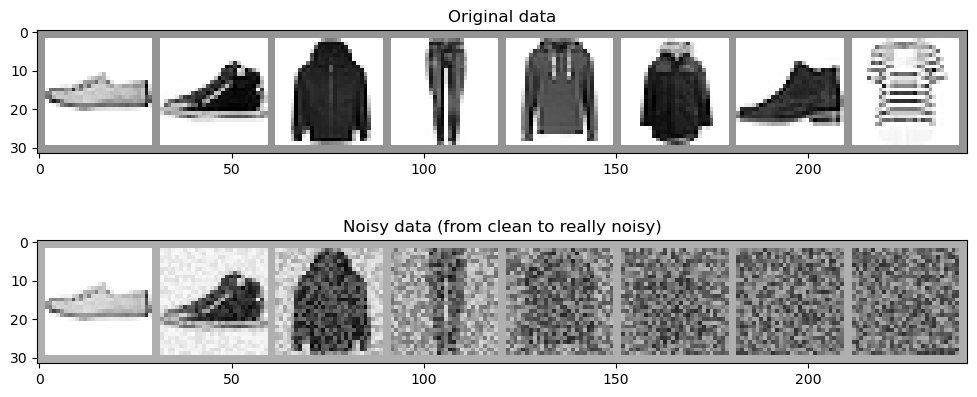

In [8]:

# Iterate on the data loader to generate a batch of images
sample_dataloader = DataLoader(dataset, batch_size=8, shuffle=True)
sample, _= next(iter(sample_dataloader))

# create a vector with the same number of item as the samples (e.g. 8), gradually increasing from 0 to 1
timesteps = 1000
t = torch.linspace(0, timesteps-2, sample.shape[0], dtype=torch.int)  
beta_schedule = torch.linspace(1e-4, 0.02, timesteps)
# Add the noise to each samples using the function we've built earlier
noisy_sample, a = DDPM_noise_gen(sample, t, beta_schedule)

# Display the samples and their reference 
ig, axs = plt.subplots(2, 1, figsize=(12, 5))
axs[0].set_title("Original data")
axs[0].imshow(torchvision.utils.make_grid(sample)[0], cmap="Greys")
# Plotting the noised version
axs[1].set_title("Noisy data (from clean to really noisy)")
axs[1].imshow(torchvision.utils.make_grid(noisy_sample)[0], cmap="Greys")


## Building and training the denoiser to generate images

We will use the next two cells to build differents variants of denoiser to compare their performance.

### Simple Denoiser 

We will start by building in the `HourGlassNet` class a simple CNN with the following architecture :

![alt text](illus/HourGlass.png "HourGlass net")

Next, complete the training loop skeleton below to train your denoiser, using the `noise_generator` function you've built earlier
The last cell will allow you to test your model. Be sure to save the image for comparison later.

### Simple Unet 

Modify your `HourGlassNet` (or create a new class) by adding some skip connections as shown in the diagram below

![alt text](illus/Unet_simple.png "Simplified UNET")

Again modify the training loop if necessary and save the outputs for comparison later.

### Simplified DDPM Unet

Using the helper functions provided at the beginning, add self-attention layers to your model. This step will bring us closer to the actual model used in the DDPM paper ([this one](https://arxiv.org/pdf/1701.05517))

![alt text](illus/DDPM_Simple.png "Simplified DDPM")

You will also need to modify the `conv2D` layers of your network and replace them with residual blocks as shown in the diagram below : 

![alt text](illus/ResBlock.png "Residual Block")

Again modify the training loop if necessary and save the outputs for comparison later.

In [9]:
# Build your custom blocks here with the class LayerBlock(nn.Module) for the DDPM UNet

# Optionnal, add groupnorm & dropout
class LayerBlock(nn.Module):

    def __init__(self, in_channels, out_channels, k_size, pad_size, act):
        super().__init__()
        self.act = act
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=k_size, padding=pad_size)
        self.conv2 = nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=k_size, padding=pad_size)
        self.attn = SelfAttention(in_channels, nn.ReLU)
        
        if in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels))
        else:
            self.skip = None
            
    def forward(self, x, time_embd, attention=False):
    
        if attention:
            x, _ = self.attn(x)
        x = x + time_embd[:, :x.shape[1], :, :]
        residual = x 
        if self.skip is not None: 
            residual = self.skip(residual)
        x = self.conv1(x)
        x = self.conv2(self.act(x))
        return self.act(x + residual)




In [10]:
# Build your networks here starting withe the simple denoising network (called hourglass here)
class HourGlassNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.act = nn.ReLU() # Or any other activation of your choixe

        # Place your layers definition (with parameters) here. Do not forget the upscaling & downscaling operations
        self.downscaling_steps = torch.nn.ModuleList(
            [
                nn.Conv2d(in_channels, 32, kernel_size=5, padding=2),
                nn.Conv2d(32, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 64, kernel_size=5, padding=2),
            ]
        )
        self.upscaling_steps = torch.nn.ModuleList(
            [
                nn.Conv2d(64, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 32, kernel_size=5, padding=2),
                nn.Conv2d(32, out_channels, kernel_size=5, padding=2),
            ]
        )

    
        self.downscale_op = nn.MaxPool2d(2)
        self.upscale_op = nn.Upsample(scale_factor=2)
        
    def forward(self, x):

        # Create your network structure here
        
        # Move through the downscaling layers
        for i, l in enumerate(self.downscaling_steps):
            x = self.act(l(x)) 

            # Apply the downscaling step only for the (N//2)-1 layers
            if i < len(self.downscaling_steps)-1: 
                x = self.downscale_op(x) 

        # Go through the upscaling layers 
        for i, l in enumerate(self.upscaling_steps):

             # Apply the downscaling step only for the (N//2)+1 to N layers
            if i > 0: 
                x = self.upscale_op(x)  
    
            x = self.act(l(x)) 
        return x

# Simpler version of UNET (with less layers)
class BasicUnet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.downscaling_steps = torch.nn.ModuleList(
            [
                nn.Conv2d(in_channels, 32, kernel_size=5, padding=2),
                nn.Conv2d(32, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 64, kernel_size=5, padding=2),
            ]
        )
        self.upscaling_steps = torch.nn.ModuleList(
            [
                nn.Conv2d(64, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 32, kernel_size=5, padding=2),
                nn.Conv2d(32, out_channels, kernel_size=5, padding=2),
            ]
        )
        self.act = nn.ReLU() # Remplacer ça par une SiLU
        self.downscale_op = nn.MaxPool2d(2)
        self.upscale_op = nn.Upsample(scale_factor=2)
        # self.SelfAttn = 
        
    def forward(self, x):

        # Initiate a buffer for skip connections content
        skip_connexion = []
        for i, l in enumerate(self.downscaling_steps):
            x = self.act(l(x)) 
            if i < 2: 
                skip_connexion.append(x) 
                x = self.downscale_op(x)  # Downscale ready for the next layer

        for i, l in enumerate(self.upscaling_steps):
            if i > 0:  # For all except the first up layer
                x = self.upscale_op(x)  # Upscale 
                x += skip_connexion.pop() 
            x = self.act(l(x))  # Through the layer and the activation function

        return x

# Simpler version of the DDPM Unet with sinusoidal embeddings
class DDPMUnet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.act = nn.ReLU() # Remplacer ça par une SiLU
        self.downscaling_steps = torch.nn.ModuleList(
            [
                LayerBlock(in_channels,32, 3, 1, self.act),
                LayerBlock(32,64, 3, 1, self.act),
                LayerBlock(64,64, 3, 1, self.act),
            ]
        )
        self.upscaling_steps = torch.nn.ModuleList(
            [
                LayerBlock(64,64, 3, 1, self.act),
                LayerBlock(64,32, 3, 1, self.act),
                LayerBlock(32, out_channels, 5, 2, self.act),

            ]
        )
        
        self.downscale_op = nn.MaxPool2d(2)
        self.upscale_op = nn.Upsample(scale_factor=2)
        self.time_embd = SinusoidalEmbeddings(time_steps=1000, embed_dim=64)
        
    def forward(self, x, t):
        skip_connexion = []
        embd = self.time_embd(x, t)
        for i, l in enumerate(self.downscaling_steps):
            x = self.act(l(x, embd, attention=False))
            if i < 2:  # For all but the third (final) down layer:
                skip_connexion.append(x)  # Storing output for skip connection
                x = self.downscale_op(x)  # Downscale ready for the next layer

        for i, l in enumerate(self.upscaling_steps):
            if i > 0:  # For all except the first up layer
                x = self.upscale_op(x)  # Upscale 
                x += skip_connexion.pop()  # Fetching stored output (skip connection)
            x = self.act(l(x,embd, attention=True))  # Through the layer and the activation function

        return x



In [13]:
# Training Logic

batch_size = 8
# [TODO] Hyperarameters
n_epochs = 1
ema_decay = 0.9999
learning_rate = 1e-3
n_steps = 1000

# [TODO] Create the network 
net = DDPMUnet()
net.to(device)

# [TODO] Set the correct loss function 
loss_fn = nn.MSELoss() 

opt = torch.optim.Adam(net.parameters(), lr=learning_rate) # Change at your own risk ;) 
train_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True) 
losses = [] # For post training visualisation of the loss variation

# [OPTIONNAL] Add EMA to your training pipeline (for better performance in theory)
# ema = ModelEmaV3(net, decay=ema_decay)

timesteps = 1000
# t = torch.linspace(0, timesteps-2, sample.shape[0], dtype=torch.int)  
beta_schedule = torch.linspace(1e-4, 0.02, timesteps)
# Add the noise to each samples using the function we've built earlier


# The training loop
for epoch in range(n_epochs):

    for x, y in tqdm(train_dataloader):
        # Get some data and prepare the corrupted version
        x = x.to(device)
        
        # Sample some time steps 
        t = torch.randint(0,n_steps-2,(batch_size,))

        # [TODO] Generate the noisy variants of x using the noise generator function
        epsilon = torch.rand_like(x)
        
        x_t, at_1  = DDPM_noise_gen(sample, t, beta_schedule)
        x_t, at_1 = x_t.to(device), at_1.to(device)
        x_t_1 = torch.sqrt(at_1)*x_t + torch.sqrt(1 - at_1)*epsilon
        x_t_1 = x_t_1.to(device)
        
        # [TODO] Process the noisy input with the denoiser
        pred = net(x_t_1,t )

        # [TODO] Compute the loss on the noise (or the image if you use the simplified denoiser)
        loss = loss_fn(pred, epsilon) 
        
        # Run the optimizer 
        opt.zero_grad()
        loss.backward()
        opt.step()

        # Uncomment/Commment if you wish to use/disable EMA
        # ema.update(net)
        
        # Store the loss in the log for visualisation
        losses.append(loss.item())
        
        

    # Display the current loss for this step
    avg_loss = sum(losses[-len(train_dataloader) :]) / len(train_dataloader)
    print(f"Finished epoch {epoch+1}. Average loss for this epoch: {avg_loss:05f}")

100%|██████████| 7500/7500 [01:52<00:00, 66.42it/s]

Finished epoch 1. Average loss for this epoch: 0.027938


(0.0, 0.5)

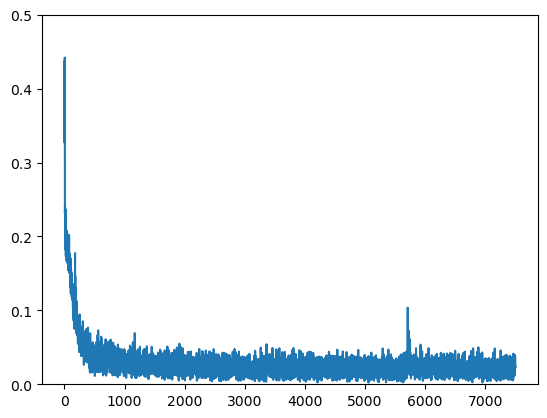

In [14]:
# Display the training loss
plt.plot(losses)
plt.ylim(0, 0.5) # Change the upper bound if needed to see the loss variations more clearly 

0it [00:00, ?it/s]
142it [00:00, 183.88it/s]
285it [00:01, 226.64it/s]
428it [00:01, 239.14it/s]
570it [00:02, 244.30it/s]
713it [00:03, 227.29it/s]
856it [00:03, 239.08it/s]
999it [00:04, 236.27it/s]


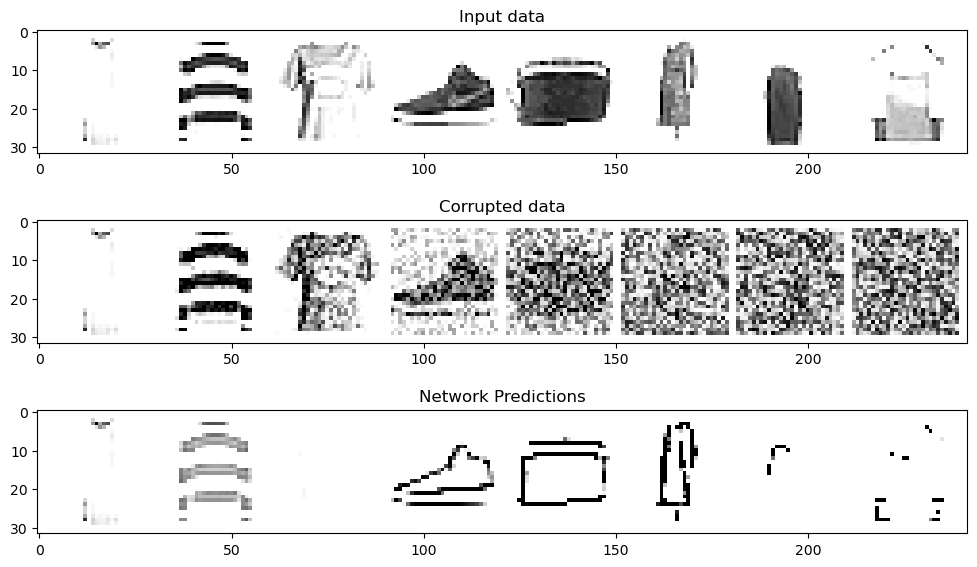

In [18]:
# Load a batch of images to see the effect of your trained model on different noise levels
test_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True) 

x, y = next(iter(test_dataloader))
x = x[:8]  # 

# Add some corruption to the samples to see the effect of the DDPM
t = torch.linspace(0, timesteps-1, sample.shape[0], dtype=torch.int)  
beta_schedule = torch.linspace(1e-4, 0.02, n_steps)

noised_x,_ = DDPM_noise_gen(x, t, beta_schedule)

# Get the model predictions
alpha_0, beta_0 = DDPM_scheduler(0, beta_schedule)

# Initiate an empty tensor to store the denoised inputs
preds = torch.empty((0,1,28,28))

with torch.no_grad():
    for idx in range(x.shape[0]): 
        
        x_in = x[idx]
        # Add a dummy 1st dimention to X_in to be able to use the model
        x_in = x_in.view(-1,1,x.shape[2], x.shape[3])
        
        for step in tqdm(reversed(range(0, t[idx]))):
            # Get alpha and beta for the specific timestep
            alpha_t, beta_t = DDPM_scheduler(step, beta_schedule)
            step = [step] # The model expect a 1D tensor (or a list)
            Beta_t = (beta_t/( (torch.sqrt(1-alpha_t))*(torch.sqrt(1-beta_t)) ))
            x_in = (1/(torch.sqrt(1-beta_t)))*x_in - (Beta_t*net(x_in.to(device), step).detach().cpu())
        
        preds = torch.cat((preds, x_in), dim=0)

# Display your results
fig, axs = plt.subplots(3, 1, figsize=(12, 7))
axs[0].set_title("Input data")
axs[0].imshow(torchvision.utils.make_grid(x)[0].clip(0, 1), cmap="Greys")
axs[1].set_title("Corrupted data")
axs[1].imshow(torchvision.utils.make_grid(noised_x)[0].clip(0, 1), cmap="Greys")
axs[2].set_title("Network Predictions")
axs[2].imshow(torchvision.utils.make_grid(preds)[0].clip(0, 1), cmap="Greys")


1000it [00:04, 200.90it/s]


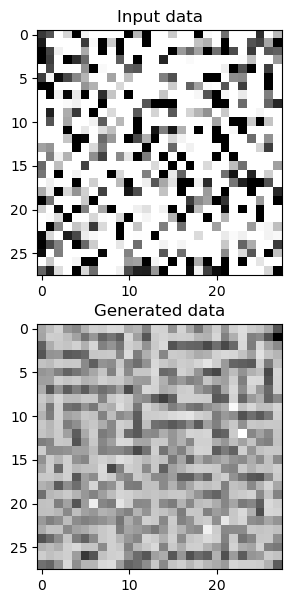

In [19]:
# Generate a random character with your network 
# You might need a few training epochs to get usable samples 
# The network need some time to capture the semantics of the training data 
fig, axs = plt.subplots(2, 1, figsize=(12, 7))

with torch.no_grad():
    # Generate random noise    
    x_in = torch.randn(1,1,28,28)
    axs[0].set_title("Input data")
    axs[0].imshow(torchvision.utils.make_grid(x_in[0][0])[0].clip(0, 1), cmap="Greys")

    for step in tqdm(reversed(range(0, timesteps))):

        alpha_t, beta_t = DDPM_scheduler(step, beta_schedule)
        step = [step] # The model expect a 1D tensor (or a list)
        Beta_t = (beta_t/( (torch.sqrt(1-alpha_t))*(torch.sqrt(1-beta_t)) ))
        x_in = (1/(torch.sqrt(1-beta_t)))*x_in - (Beta_t*net(x_in.to(device), step).detach().cpu())
axs[1].set_title("Generated data")  
axs[1].imshow(x_in[0][0], cmap="Greys")